https://github.com/4GeeksAcademy/decision-tree-project-tutorial/blob/main/solution.es.ipynb

In [65]:
import numpy as np
import pandas as pd
import missingno as msno
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, RandomizedSearchCV
from missforest import MissForest
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.inspection import permutation_importance
from xgboost import XGBClassifier
import shap
from statsmodels.tools.tools import add_constant
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.tree import DecisionTreeClassifier, export_text #https://scikit-learn.org/stable/modules/tree.html
from sklearn import tree
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
from imblearn.metrics import specificity_score
from scipy.stats import randint
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from pickle import dump
import warnings
warnings.filterwarnings('ignore')

In [2]:
# FUNCIONES
## Formato 5 decimales
pd.options.display.float_format = '{:,.5f}'.format 

## Metricas de clasificacion
def metricas_clas(y_train, y_test, y_pred_train, y_pred_test):
    # Calcular métricas para el conjunto de entrenamiento
    train_accuracy = accuracy_score(y_train, y_pred_train)
    train_f1 = f1_score(y_train, y_pred_train)
    train_precision = precision_score(y_train, y_pred_train)
    train_recall = recall_score(y_train, y_pred_train)
    train_specificity = specificity_score(y_train, y_pred_train)

    # Calcular métricas para el conjunto de prueba
    test_accuracy = accuracy_score(y_test, y_pred_test)
    test_f1 = f1_score(y_test, y_pred_test)
    test_precision = precision_score(y_test, y_pred_test)
    test_recall = recall_score(y_test, y_pred_test)
    test_specificity = specificity_score(y_test, y_pred_test)

    # Calcular la diferencia entre métricas de entrenamiento y prueba
    diff_accuracy = train_accuracy - test_accuracy
    diff_f1 = train_f1 - test_f1
    diff_precision = train_precision - test_precision
    diff_recall = train_recall - test_recall
    diff_specificity = train_specificity - test_specificity

    # Crear un DataFrame con los resultados
    metrics_df = pd.DataFrame([[train_accuracy,train_recall,train_specificity,train_precision,train_f1],
                               [test_accuracy, test_recall, test_specificity, test_precision,test_f1],
                               [diff_accuracy, diff_recall, diff_specificity, diff_precision, diff_f1]],
                              columns = ['Accuracy', 'Recall', 'Specificity', 'Precision', 'F1'],
                              index = ['Train','Test', 'Diferencia'])

    return metrics_df

#Observaciones fuera del ric
def oulier_ric(df):
    obs=[]
    for var in df.columns:
        rango=df[var].quantile(0.75)-df[var].quantile(0.25)
        ric_lis=[df[var].quantile(0.25)-1.5*rango, df[var].quantile(0.75)+1.5*rango]
        obs.append(len(df[(df[var]<ric_lis[0])|(df[var]>ric_lis[1])])/X_train_imp.shape[0]*100)
    return pd.Series(obs, index=df.columns).sort_values(ascending=False)

#Desviación media-mediana
def outlier_med(df):
    ratio=[]
    for var in df.columns:
        ratio.append(np.abs(df[var].mean()-df[var].median())/df[var].median()*100)
    return pd.Series(ratio, index=df.columns).sort_values(ascending=False)

# **0. CONTEXTO Y CARGA DATOS**

Fuente: https://github.com/4GeeksAcademy/random-forest-project-tutorial/blob/main/README.es.md

Descripción del proyecto:

Este conjunto de datos proviene originalmente del Instituto Nacional de Diabetes y Enfermedades Digestivas y Renales. El objetivo es predecir en base a medidas diagnósticas si un paciente tiene o no diabetes.


Descripción de variables: 

- Pregnancies. Número de embarazos del paciente (numérico)

- Glucose. Concentración de glucosa en plasma a las 2 horas de un test de tolerancia oral a la glucosa (numérico)

- BloodPressure. Presión arterial diastólica (medida en mm Hg) (numérico)

- SkinThickness. Grosor del pliegue cutáneo del tríceps (medida en mm) (numérico)

- Insulin. Insulina sérica de 2 horas (medida en mu U/ml) (numérico)

- BMI. Índice de masa corporal (numérico)

- DiabetesPedigreeFunction. Función de pedigrí de diabetes (numérico)

- Age. Edad del paciente (numérico)

- Outcome. Variable de clase (0 o 1), siendo 0 negativo en diabetes y 1, positivo (numérico)

In [3]:
#Cargamos la base de datos en crudo
df=pd.read_csv("https://breathecode.herokuapp.com/asset/internal-link?id=930&path=diabetes.csv")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [4]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.60000,0.62700,50,1
1,1,85,66,29,0,26.60000,0.35100,31,0
2,8,183,64,0,0,23.30000,0.67200,32,1
3,1,89,66,23,94,28.10000,0.16700,21,0
4,0,137,40,35,168,43.10000,2.28800,33,1


# **1. CRIBADO MANUAL**

## 1.1. Verificar valores

### 1.1.1. Unicos

In [5]:
#Valores unicos por cada columna
unicos=df.nunique()
print("No hay columnas con valores únicos" if sum(unicos==1)==0 else "Hay columnas con valores únicos")

No hay columnas con valores únicos


### 1.1.2. Eliminación de filas y columnas duplicadas

In [6]:
#Indice
dup_fil=df.duplicated().sum()
print("No hay filas duplicadas" if dup_fil==0 else "Hay filas duplicadas")

No hay filas duplicadas


In [7]:
#Trasponemos las columnas para verificar que toda la fila (variable) no sea igual a otra
dup_col=df.T.duplicated(keep=False).sum()
print("No hay variables exactamente iguales" if dup_col==0 else "Hay variables exactamente iguales")

No hay variables exactamente iguales


## 1.2. Verificar missing values

In [8]:
# Columnas columnas con más de un 15% de valores faltantes
missing=df.isna().mean()*100
missing[missing>15]

Series([], dtype: float64)

<Axes: >

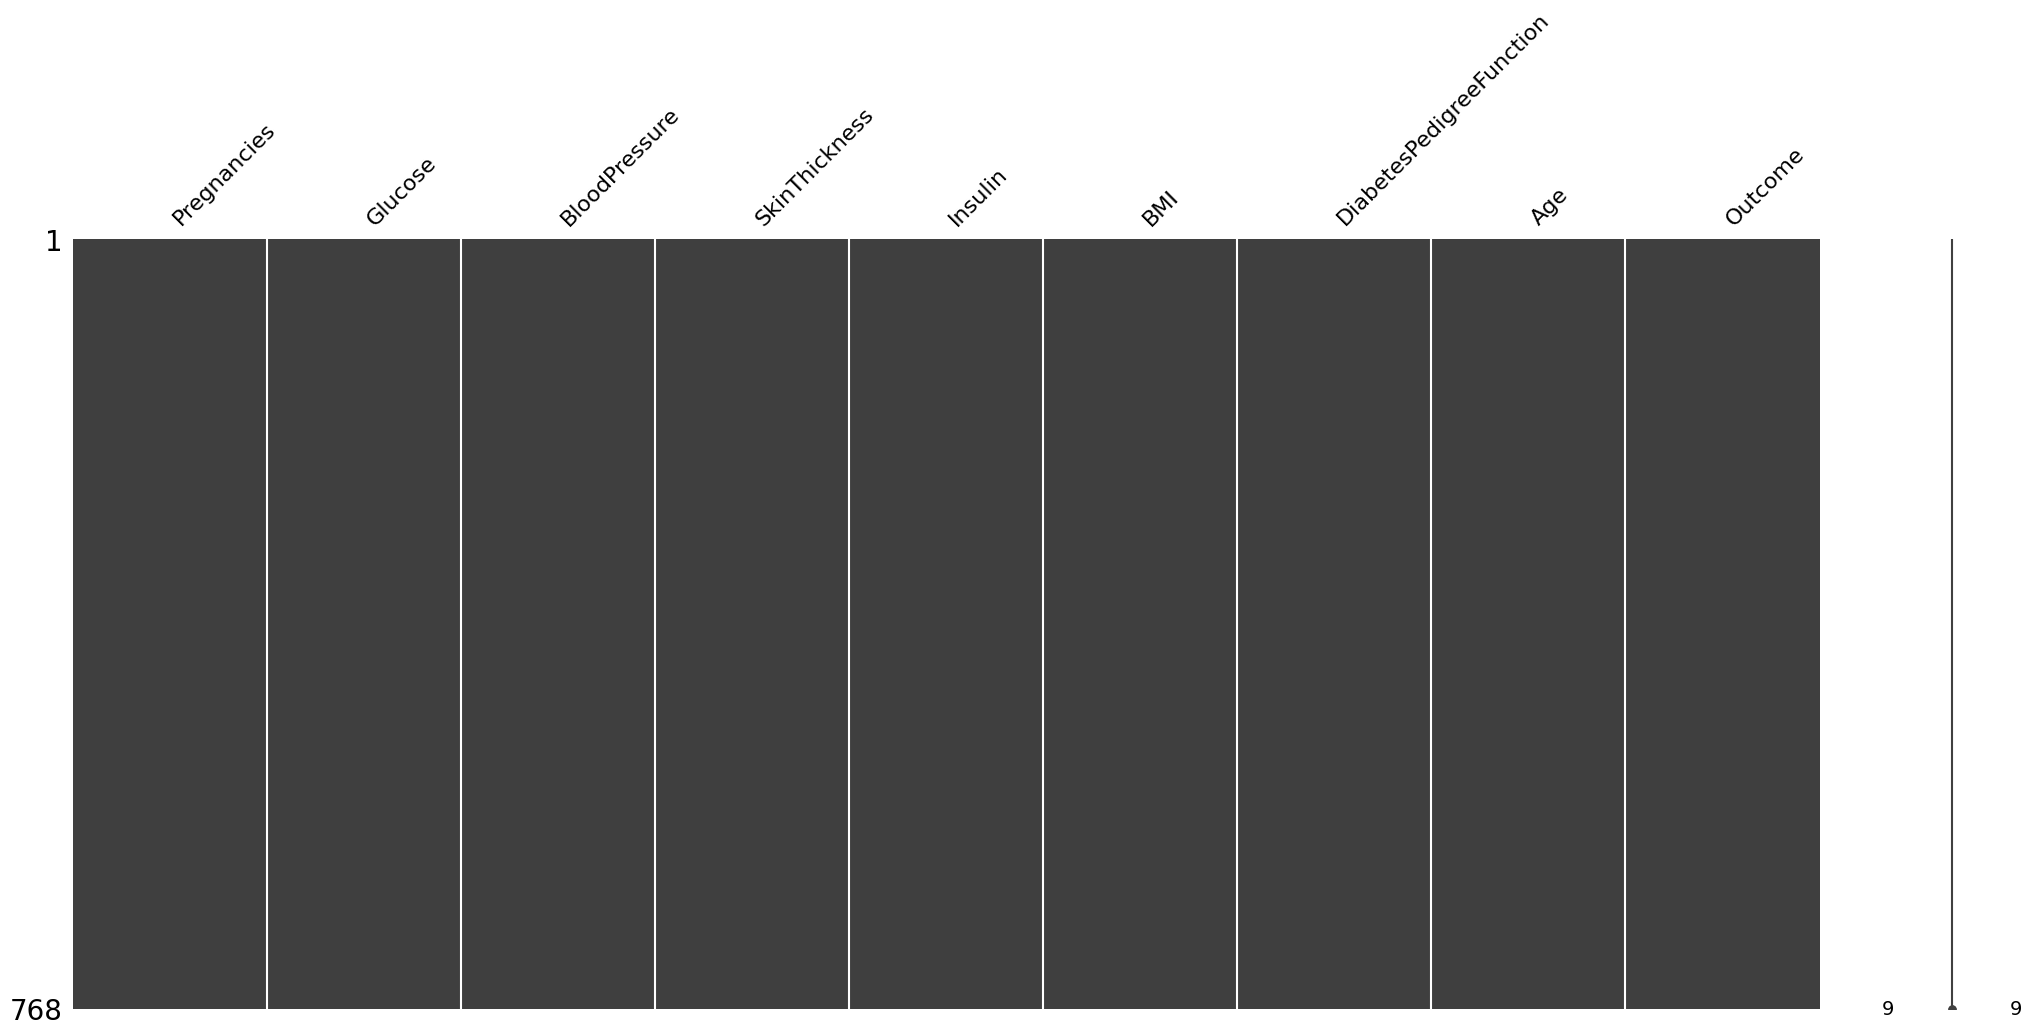

In [9]:
# Gráficamente
msno.matrix(df)

## 1.3. Análisis Univariante

### 1.3.1. Variables numéricas

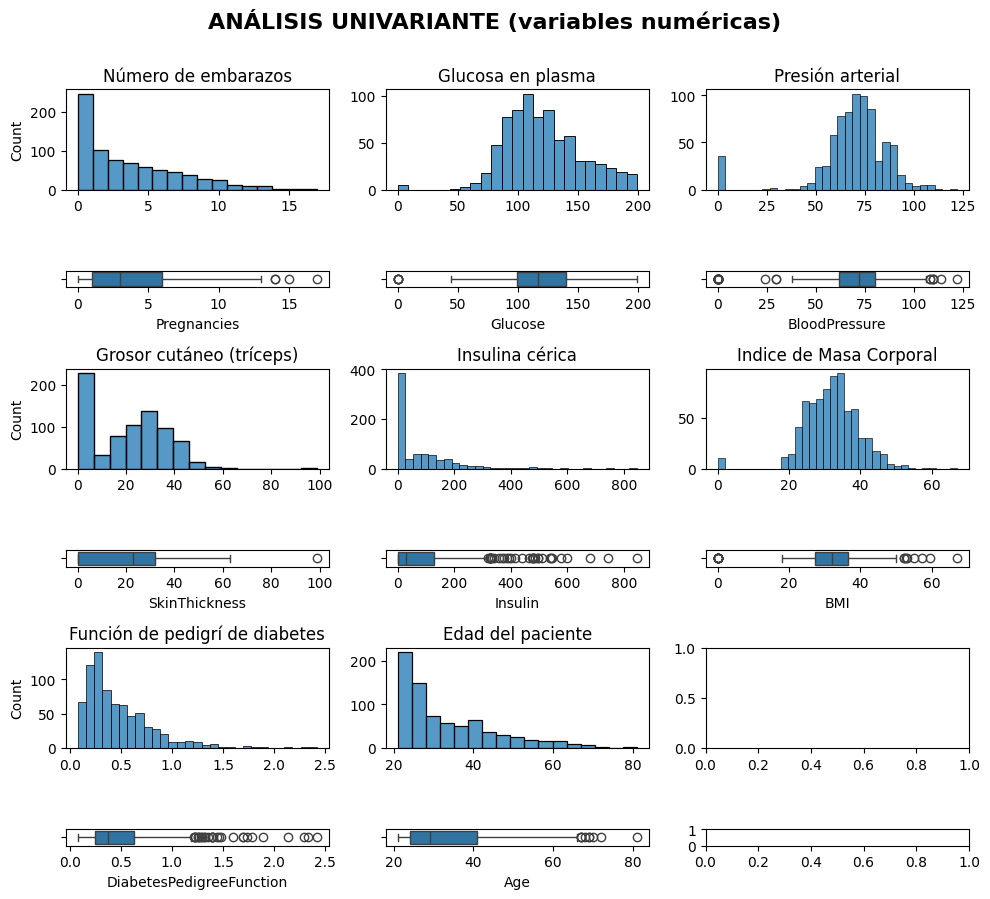

In [10]:
fig, axis = plt.subplots(6, 3, figsize = (10, 10), gridspec_kw={'height_ratios': [6, 1, 6, 1, 6, 1]}) #height_ratios: cambiar tamaño relativo de los graficos

#Primera Fila
sns.histplot(ax = axis[0, 0], data = df, x = "Pregnancies").set(xlabel = None)
sns.boxplot(ax = axis[1, 0], data = df, x = "Pregnancies")
axis[0, 0].set_title("Número de embarazos")
sns.histplot(ax = axis[0, 1], data = df, x = "Glucose").set(xlabel = None, ylabel = None)
sns.boxplot(ax = axis[1, 1], data = df, x = "Glucose")
axis[0, 1].set_title("Glucosa en plasma")
sns.histplot(ax = axis[0, 2], data = df, x = "BloodPressure").set(xlabel = None, ylabel = None)
sns.boxplot(ax = axis[1, 2], data = df, x = "BloodPressure")
axis[0, 2].set_title("Presión arterial")

#Segunda Fila
sns.histplot(ax = axis[2, 0], data = df, x = "SkinThickness").set(xlabel = None)
sns.boxplot(ax = axis[3, 0], data = df, x = "SkinThickness")
axis[2, 0].set_title("Grosor cutáneo (tríceps)")
sns.histplot(ax = axis[2, 1], data = df, x = "Insulin").set(xlabel = None, ylabel = None)
sns.boxplot(ax = axis[3, 1], data = df, x = "Insulin")
axis[2, 1].set_title("Insulina cérica")
sns.histplot(ax = axis[2, 2], data = df, x = "BMI").set(xlabel = None, ylabel = None)
sns.boxplot(ax = axis[3, 2], data = df, x = "BMI")
axis[2, 2].set_title("Indice de Masa Corporal")

#Tercera Fila
sns.histplot(ax = axis[4, 0], data = df, x = "DiabetesPedigreeFunction").set(xlabel = None)
sns.boxplot(ax = axis[5, 0], data = df, x = "DiabetesPedigreeFunction")
axis[4, 0].set_title("Función de pedigrí de diabetes")
sns.histplot(ax = axis[4, 1], data = df, x = "Age").set(xlabel = None, ylabel = None)
sns.boxplot(ax = axis[5, 1], data = df, x = "Age")
axis[4, 1].set_title("Edad del paciente")

# Ajustes visuales
plt.subplots_adjust(hspace=0.5, wspace=0.3) # hspace: Espacio vertical | wspace: Espacio horizontal
fig.suptitle("ANÁLISIS UNIVARIANTE (variables numéricas)", fontsize=16, fontweight="bold", y=0.955)
# rect=[0, 0.03, 1, 0.95] ajusta los márgenes para que el suptitle no corte los gráficos.
plt.tight_layout(rect=[0, 0.06, 1, 0.95])
plt.show()

#### Tratamiento de valores extraños

Tras investigar en diferentes fuentes, los rango observados en la realidad abarcan estos valores:
- Glucosa: valores normales 16-166 mlU/L
    - Fuente: https://www.metropolisindia.com/blog/preventive-healthcare/what-is-an-insulin-test-its-uses-and-test-results#:~:text=are%20working%20efficiently.-,Understanding%20the%20Test%20Results%20of%20the%20Fasting%20Insulin%20Test,depend%20on%20factors%20such%20as
- Presion aterial sistolica: valores normales 80-120
    - Fuente: https://www.heart.org/en/health-topics/high-blood-pressure/understanding-blood-pressure-readings#:~:text=Use%20our%20blood%20pressure%20chart%20to%20learn,and%20the%20difference%20between%20systolic%20and%20diastolic.
- Grosor de la piel: valores normales 5-32
    - Fuente https://pmc.ncbi.nlm.nih.gov/articles/PMC4579544/
- Insulina: valores normales 20-250
    - Fuente: https://www.apollohospitals.com/diagnostics-investigations/insulin-test#:~:text=Normal%20Range%20for%20the%20Insulin,and%20monitoring%20several%20health%20conditions:
- IMC: valores normales 18.5-24.9
    - Fuente: https://institutojesuslago.com/en/imc-calculator.php

Con esta información, podemos deducir que los valores 0 observados en el gráfico son nulos.

<Axes: >

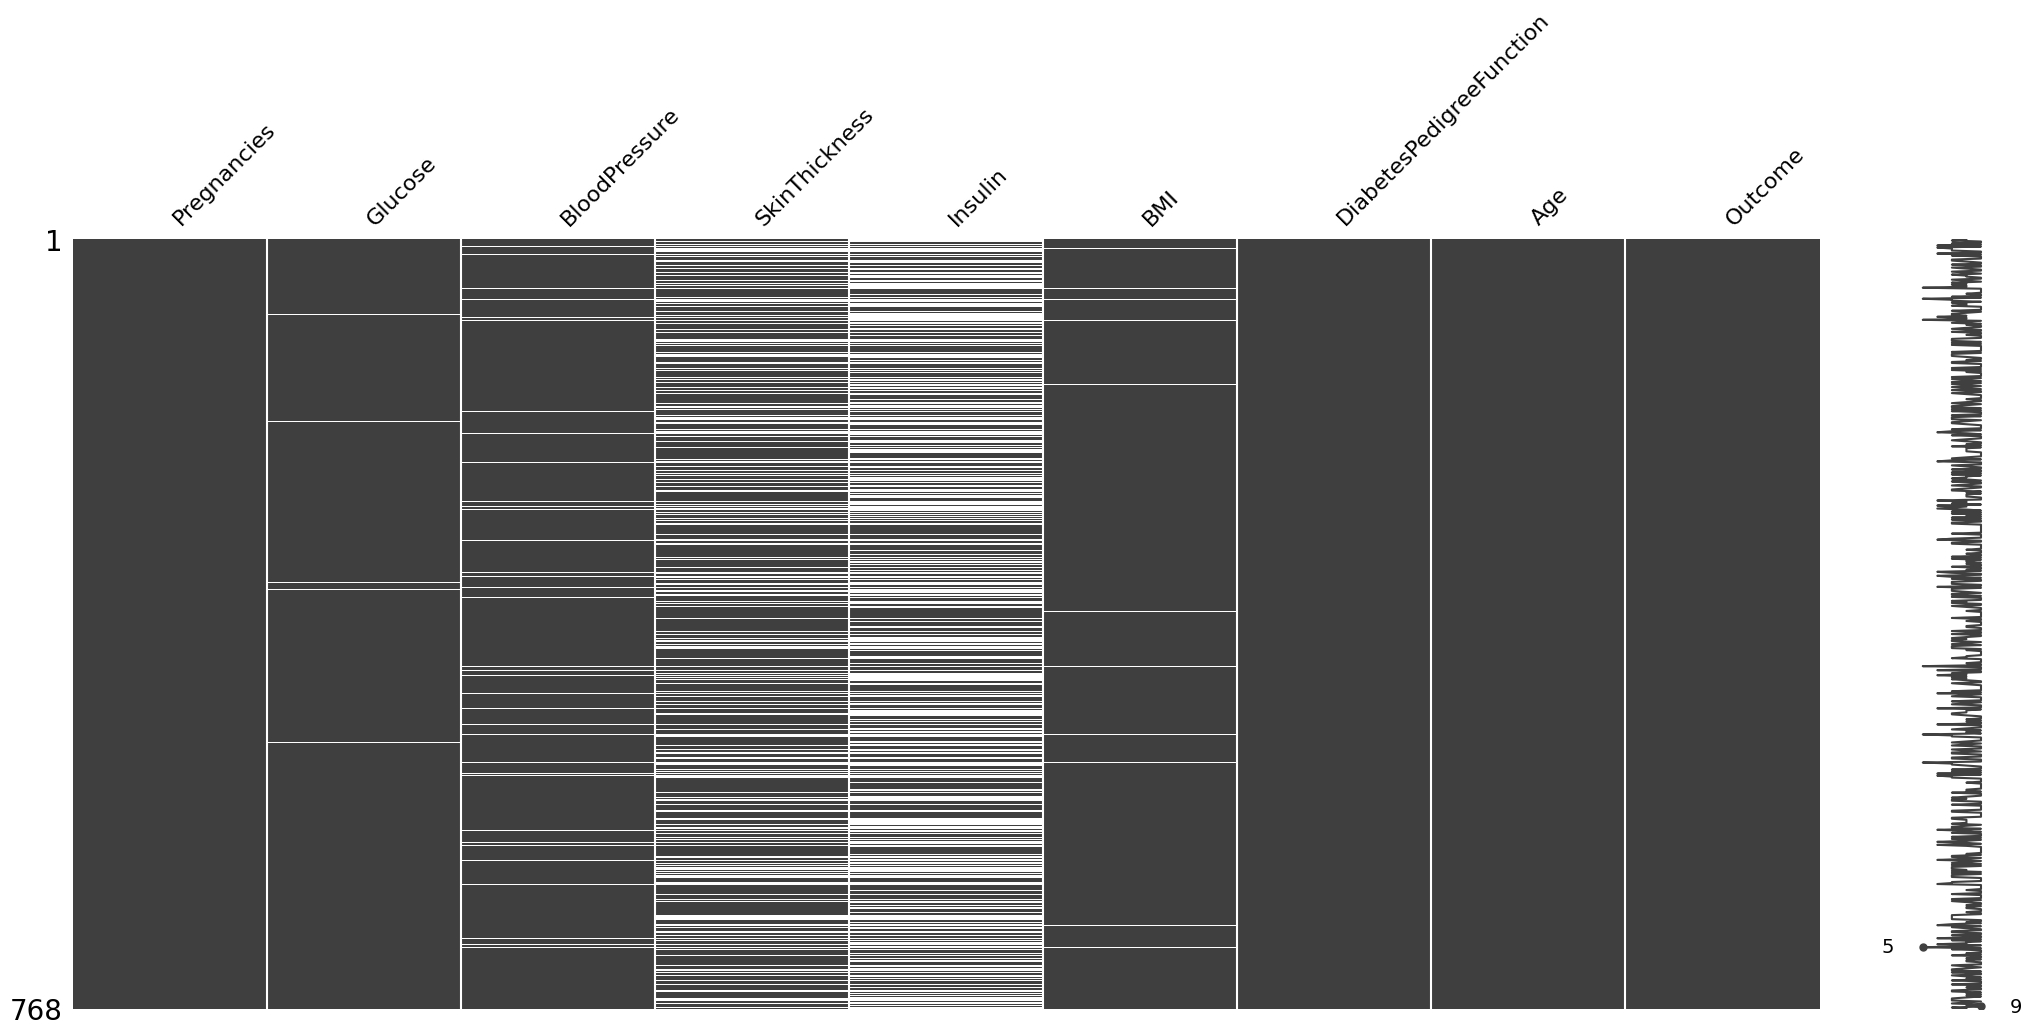

In [11]:
columnas=["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]
#Iteramos por las columnas anteriores para imputar 0 como NaN
for var in columnas:
    df.loc[df[var]==0, var]=np.nan

# Mostramos msno ahora
msno.matrix(df)

In [12]:
# Variables con más de un 20% de valores faltantes
col_na=df.isna().sum()/len(df)
col_na[col_na>0.2]

SkinThickness   0.29557
Insulin         0.48698
dtype: float64

In [13]:
# Busqueda de patrones dentro de insulina
df[df["Insulin"].isna()].describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,374.00000,370.00000,339.00000,147.00000,0.00000,364.00000,374.00000,374.00000,374.00000
mean,4.43316,120.70000,74.43953,29.27891,NaN,31.79341,0.41534,35.79679,0.36898
std,3.43762,30.23860,11.97971,10.43820,NaN,6.76352,0.30055,12.72903,0.48318
min,0.00000,44.00000,44.00000,8.00000,NaN,18.20000,0.07800,21.00000,0.00000
25%,1.00000,100.25000,66.00000,22.00000,NaN,26.80000,0.20900,25.00000,0.00000
50%,4.00000,115.00000,74.00000,30.00000,NaN,31.20000,0.30250,32.00000,0.00000
75%,7.00000,138.00000,82.00000,35.50000,NaN,35.72500,0.55325,43.00000,1.00000
max,14.00000,199.00000,122.00000,99.00000,NaN,52.90000,1.89300,72.00000,1.00000


Dado que no se observa ningún patrón en los datos faltantes de insulina y que estos representan entorno al 50% del total de observaciones de la muestra, procederemos a eliminar dicha variable.

In [14]:
# Eliminamos la columna al no observar ningun patron
df.drop(columns="Insulin", inplace=True)

In [15]:
#Verificamos si hay filas que tiene más de 3 columnas con NaN (37.5%)
filas=df.T.isna().sum()
print("No hay filas con más de 3 variables sin valores" if len(filas[filas>=3])==0 
      else f"Hay {len(filas[filas>=3])} observaciones con más de 3 variables sin valores")

Hay 7 observaciones con más de 3 variables sin valores


In [16]:
#Visualizamos las filas para analizar patrones
df.iloc[filas[filas>=3].index]

,Pregnancies,Glucose,BloodPressure,SkinThickness,BMI,DiabetesPedigreeFunction,Age,Outcome
49,7,105.00000,NaN,NaN,NaN,0.30500,24,0
60,2,84.00000,NaN,NaN,NaN,0.30400,21,0
81,2,74.00000,NaN,NaN,NaN,0.10200,22,0
426,0,94.00000,NaN,NaN,NaN,0.25600,25,0
494,3,80.00000,NaN,NaN,NaN,0.17400,22,0
522,6,114.00000,NaN,NaN,NaN,0.18900,26,0
706,10,115.00000,NaN,NaN,NaN,0.26100,30,1


De nuevo, eliminaremos estas observaciones pues contienen desmasiados valores faltantes como para plantear la imputación.

In [17]:
# Eliminamos observaciones al no haber ningun patron
elm_fil=filas[filas>=3].index
df.drop(elm_fil, axis=0, inplace=True)

In [18]:
print(f"Variables resultanes: {list(df.columns)}")

Variables resultanes: ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']


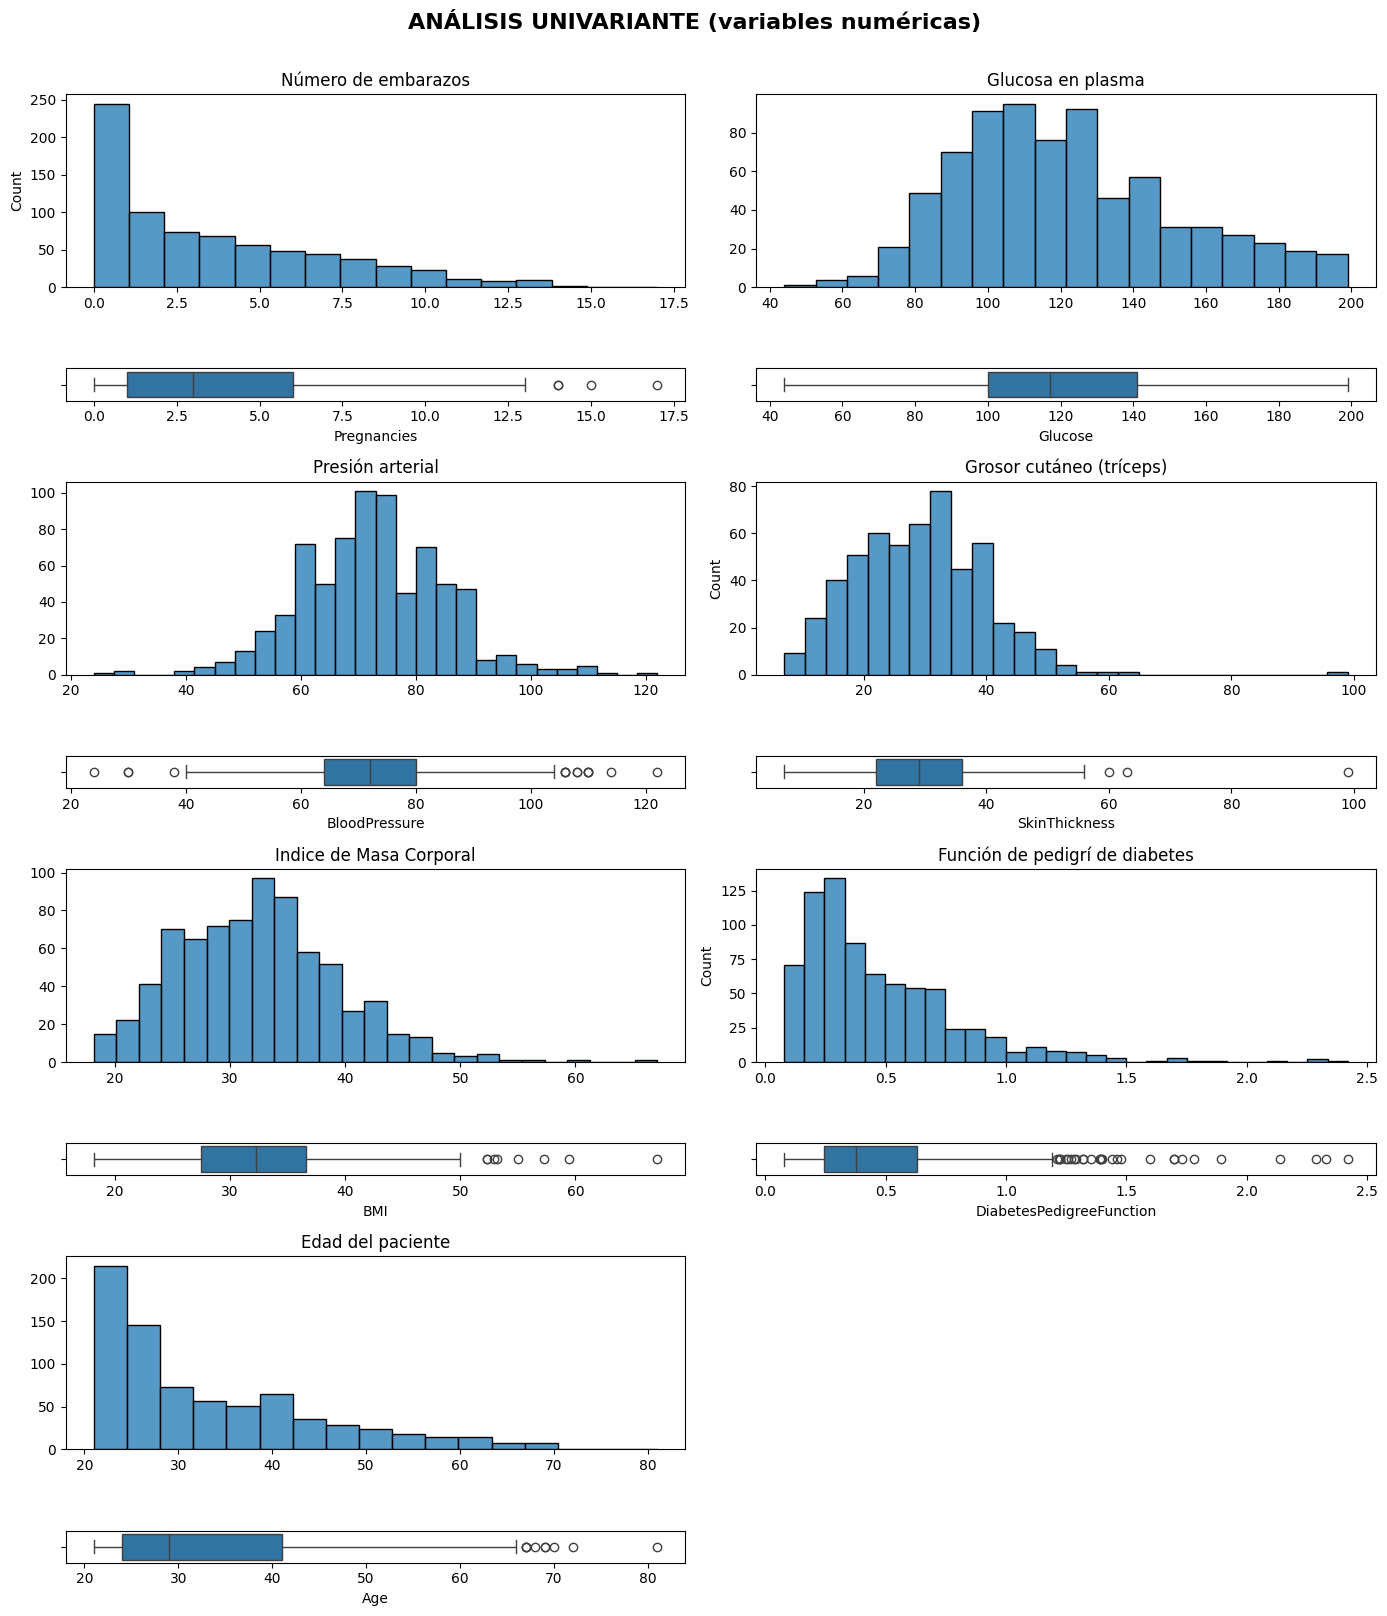

In [19]:
# Visualizamos la base de datos resultante
fig, axis = plt.subplots(8, 2, figsize = (14, 18), gridspec_kw={'height_ratios': [6, 1, 6, 1, 6, 1, 6, 1]}) #height_ratios: cambiar tamaño relativo de los graficos

#Primera Fila
sns.histplot(ax = axis[0, 0], data = df, x = "Pregnancies").set(xlabel = None)
sns.boxplot(ax = axis[1, 0], data = df, x = "Pregnancies")
axis[0, 0].set_title("Número de embarazos")
sns.histplot(ax = axis[0, 1], data = df, x = "Glucose").set(xlabel = None, ylabel = None)
sns.boxplot(ax = axis[1, 1], data = df, x = "Glucose")
axis[0, 1].set_title("Glucosa en plasma")

#Segunda Fila
sns.histplot(ax = axis[2, 0], data = df, x = "BloodPressure").set(xlabel = None, ylabel = None)
sns.boxplot(ax = axis[3, 0], data = df, x = "BloodPressure")
axis[2, 0].set_title("Presión arterial")
sns.histplot(ax = axis[2, 1], data = df, x = "SkinThickness").set(xlabel = None)
sns.boxplot(ax = axis[3, 1], data = df, x = "SkinThickness")
axis[2, 1].set_title("Grosor cutáneo (tríceps)")

#Tercera Fila
sns.histplot(ax = axis[4, 0], data = df, x = "BMI").set(xlabel = None, ylabel = None)
sns.boxplot(ax = axis[5, 0], data = df, x = "BMI")
axis[4, 0].set_title("Indice de Masa Corporal")
sns.histplot(ax = axis[4, 1], data = df, x = "DiabetesPedigreeFunction").set(xlabel = None)
sns.boxplot(ax = axis[5, 1], data = df, x = "DiabetesPedigreeFunction")
axis[4, 1].set_title("Función de pedigrí de diabetes")

#Cuarta Fila
sns.histplot(ax = axis[6, 0], data = df, x = "Age").set(xlabel = None, ylabel = None)
sns.boxplot(ax = axis[7, 0], data = df, x = "Age")
axis[6, 0].set_title("Edad del paciente")
axis[6,1].remove()
axis[7,1].remove()

# Ajustes visuales
plt.subplots_adjust(hspace=0.6, wspace=0.3) # hspace: Espacio vertical | wspace: Espacio horizontal
fig.suptitle("ANÁLISIS UNIVARIANTE (variables numéricas)", fontsize=16, fontweight="bold", y=0.955)
# rect=[0, 0.03, 1, 0.95] ajusta los márgenes para que el suptitle no corte los gráficos.
plt.tight_layout(rect=[0, 0.06, 1, 0.95])
plt.show()

### 1.3.2. Target

[]

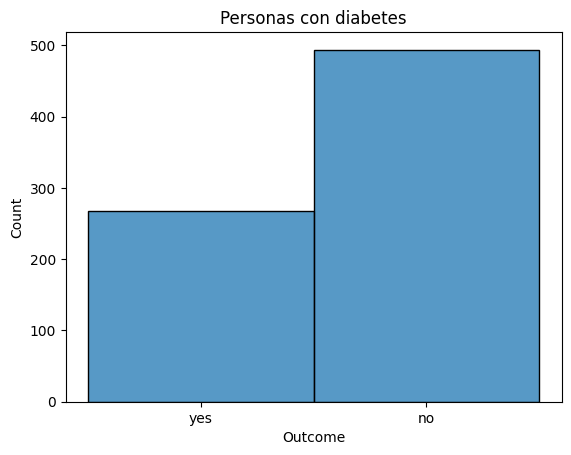

In [20]:
sns.histplot(df["Outcome"].replace({0: "no", 1:"yes"}))
plt.title("Personas con diabetes")
plt.plot()

A través de este gráfico, podemos osbervar que estamos trabajando con una base de datos desbalanceada.

## 1.4. Análisis Multivariante (Numérico-Categorico)

### 1.4.1. Matriz de correlaciones 

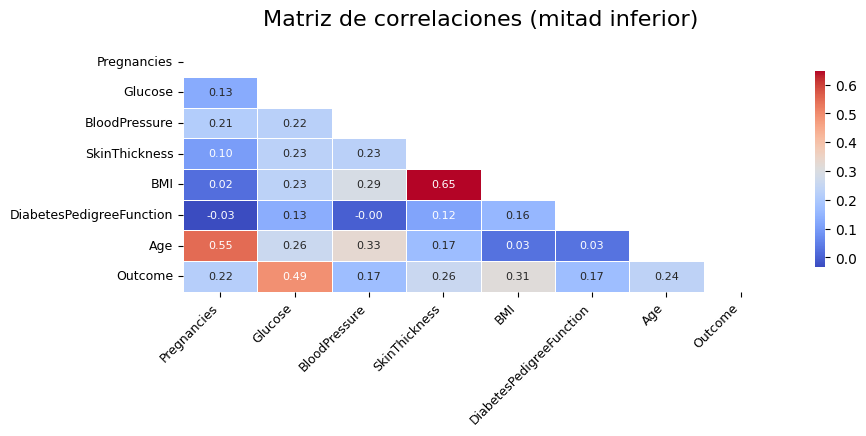

In [21]:
#Mapa de correlaciones
plt.figure(figsize=(10, 5))
sns.heatmap(
    df.corr(), mask=np.triu(np.ones_like(df.corr(), dtype=bool)), 
    cmap='coolwarm',
    annot=True, fmt=".2f", linewidths=.5,
    cbar_kws={"shrink": .8},
    annot_kws={"size": 8}
)
plt.title("Matriz de correlaciones (mitad inferior)", fontsize=16, pad=15)
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(fontsize=9)
plt.tight_layout(pad=3.0)
plt.show()

En este caso, podemos ver una fuerte relación entre:
- **Age-Pregnancies**, lo cual será abordado creando una nueva variable de embarazos por cada 5 años de edad fértil (20-52 años) dado que hay una relación directa entre ambas. Es decir, es poco probable que una persona con 80 años vaya a tener un hijo, solo nos importa cuantos tuvo en su edad fértil.

- **SkinThickness-BMI**, lo cual será evaluado en selección de características.

In [22]:
# Limite máximo de fertilidad (fuente: https://www.quironsalud.com/blogs/es/aventura-madre/edad-ideal-madre-primeriza#:~:text=La%20edad%20reproductiva%20de%20la,%C3%B3vulos%20de%20una%20mujer%20disminuye.)
df["Fertil_max"]=52 #
df.loc[df["Age"]<52, "Fertil_max"]=df.loc[df["Age"]<52, "Age"]

# Limite mínimo: edad mínima de la base de datos
df["Fertil_min"]=df["Age"].min()-1

# Años fértiles
df["FerAge"]=df["Fertil_max"]-df["Fertil_min"]

# VARIABLE OBJETIVO: embarazos por cada 5 años potencialmente fértiles
df["Pregna/Age"]=df["Pregnancies"]/(df["FerAge"]/5)

In [23]:
# Eliminamos variables utilizadas para la transformación 
col_elm=["Fertil_max", "Fertil_min", "FerAge"]
df.drop(columns=col_elm, inplace=True)
df.columns

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'BMI',
       'DiabetesPedigreeFunction', 'Age', 'Outcome', 'Pregna/Age'],
      dtype='object')

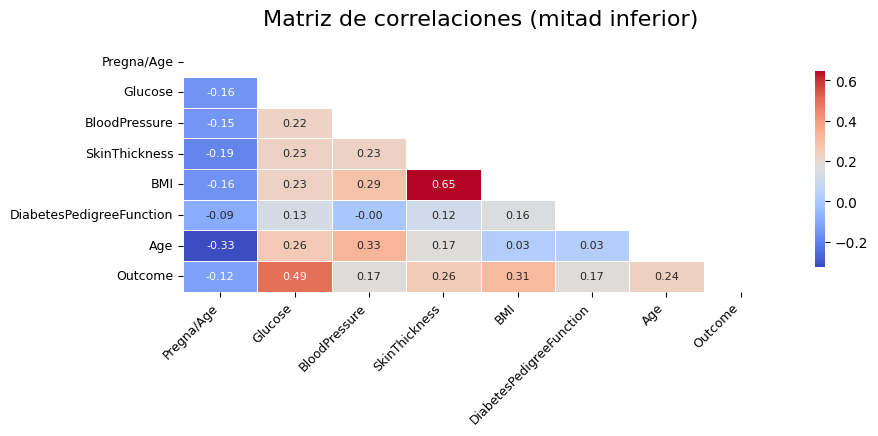

In [24]:
df_corr=df[['Pregna/Age', 'Glucose', 'BloodPressure', 'SkinThickness', 'BMI',
       'DiabetesPedigreeFunction', 'Age', 'Outcome']]
# Mostramos matriz con correcciones
plt.figure(figsize=(10, 5))
sns.heatmap(
    df_corr.corr(), mask=np.triu(np.ones_like(df_corr.corr(), dtype=bool)), 
    cmap='coolwarm',
    annot=True, fmt=".2f", linewidths=.5,
    cbar_kws={"shrink": .8},
    annot_kws={"size": 8}
)
plt.title("Matriz de correlaciones (mitad inferior)", fontsize=16, pad=15)
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(fontsize=9)
plt.tight_layout(pad=3.0)
plt.show()

### 1.4.2. Box plot por outcome

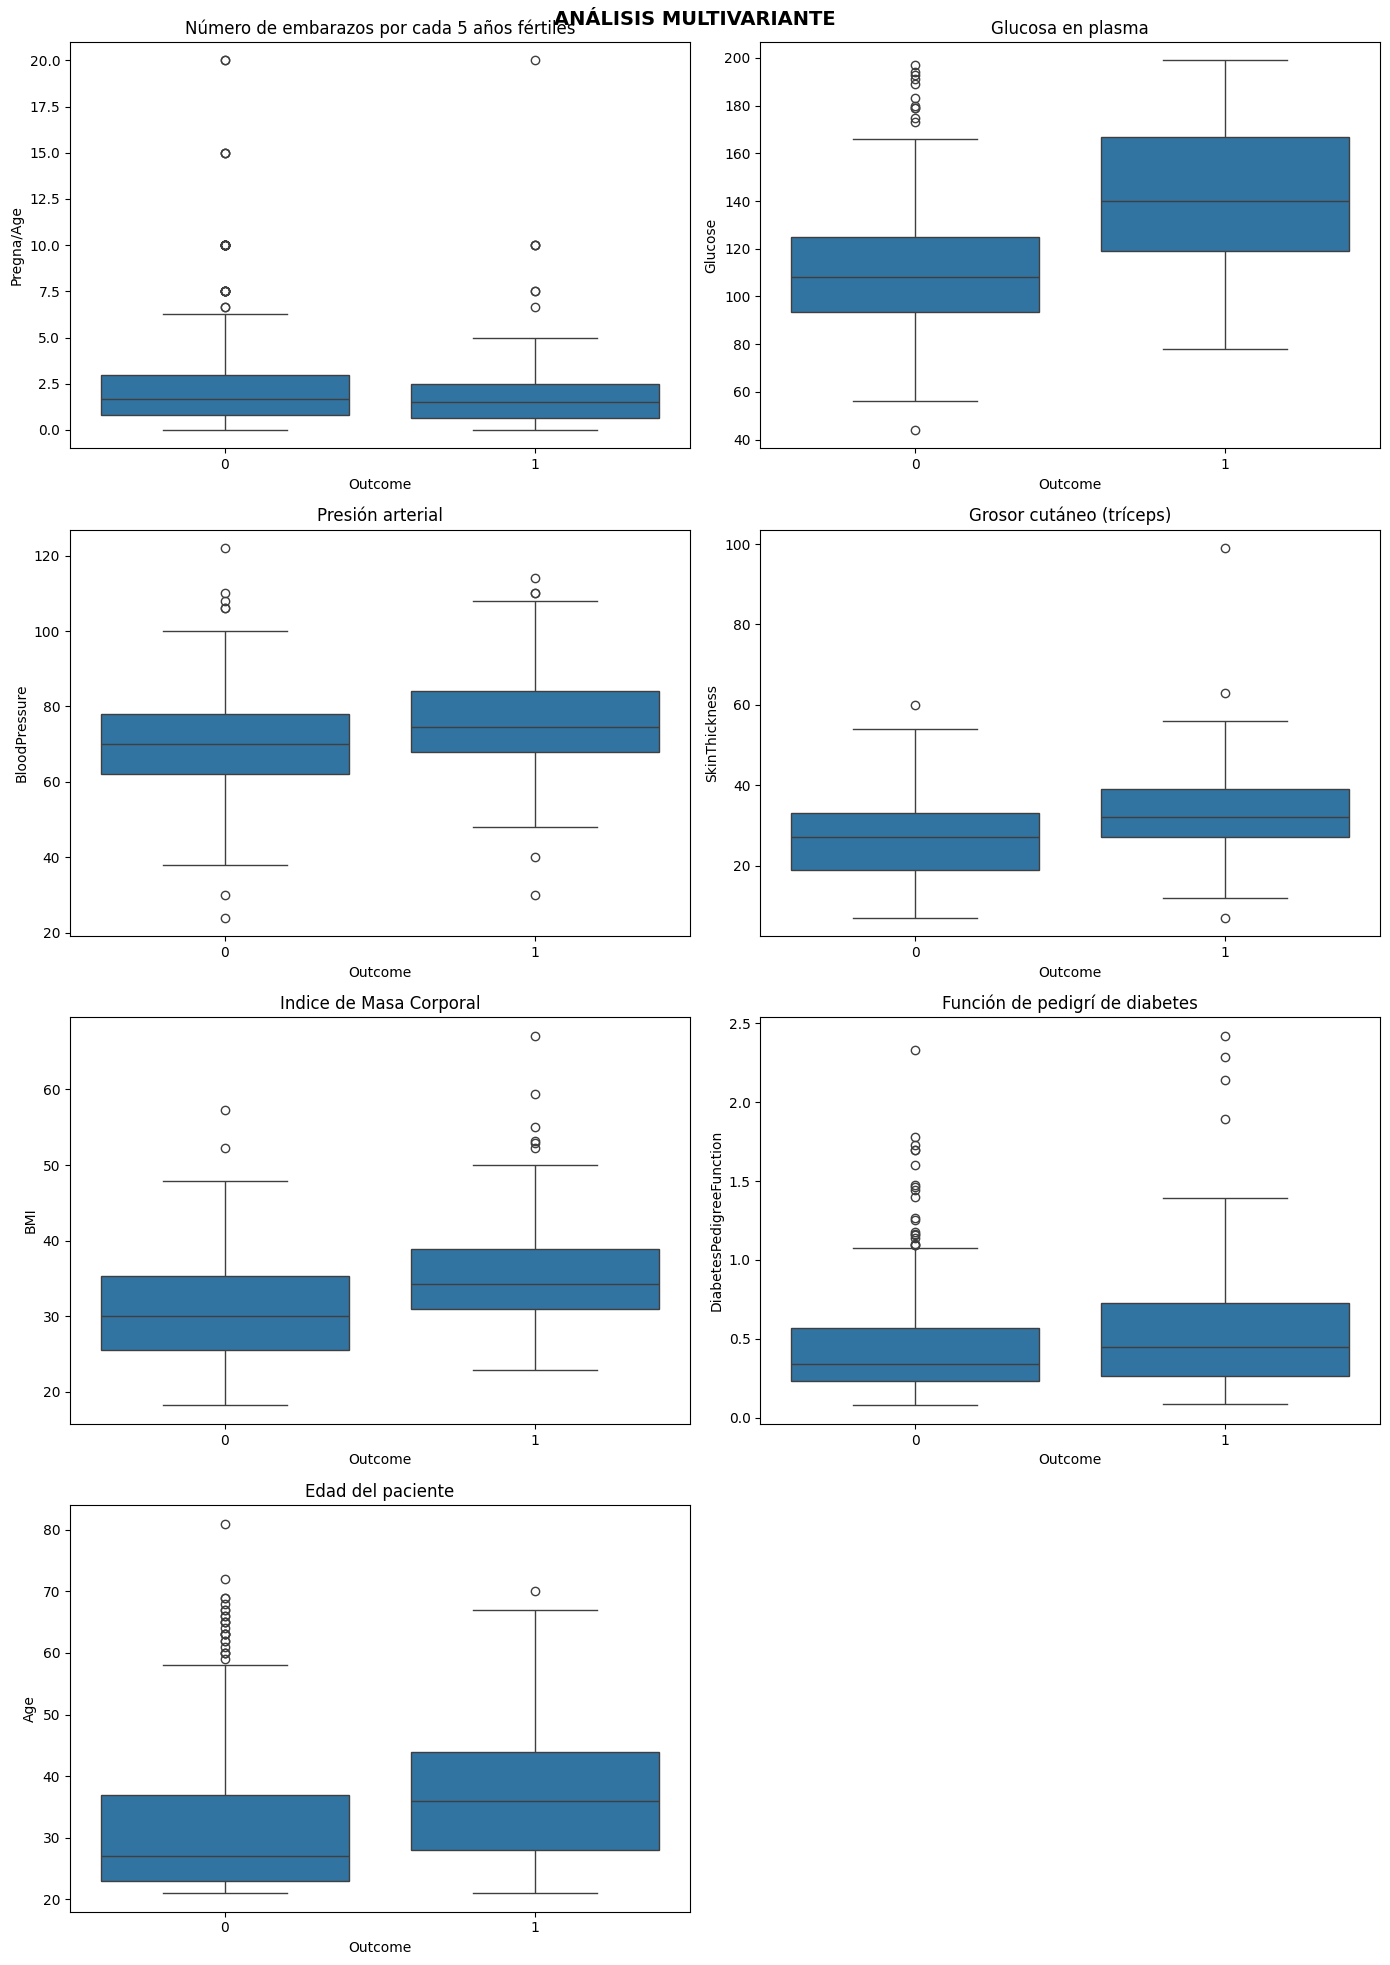

In [25]:
# Diabetes por cada variable
fig, axis = plt.subplots(4, 2, figsize = (14, 20))

#Primera Fila
sns.boxplot(ax = axis[0, 0], data = df, x="Outcome", y = "Pregna/Age")
axis[0, 0].set_title("Número de embarazos por cada 5 años fértiles")
sns.boxplot(ax = axis[0, 1], data = df, x="Outcome", y = "Glucose")
axis[0, 1].set_title("Glucosa en plasma")

#Segunda Fila
sns.boxplot(ax = axis[1, 0], data = df, x="Outcome", y = "BloodPressure")
axis[1, 0].set_title("Presión arterial")
sns.boxplot(ax = axis[1, 1], data = df, x="Outcome", y = "SkinThickness")
axis[1, 1].set_title("Grosor cutáneo (tríceps)")

#Tercera Fila
sns.boxplot(ax = axis[2, 0], data = df, x="Outcome", y ="BMI")
axis[2, 0].set_title("Indice de Masa Corporal")
sns.boxplot(ax = axis[2, 1], data = df, x="Outcome", y ="DiabetesPedigreeFunction")
axis[2, 1].set_title("Función de pedigrí de diabetes")

#Cuarta Fila
sns.boxplot(ax = axis[3, 0], data = df, x="Outcome", y ="Age")
axis[3, 0].set_title("Edad del paciente")
axis[3, 1].remove()

# Ajustes visuales
fig.suptitle("ANÁLISIS MULTIVARIANTE", fontsize=14, fontweight="bold")
# rect=[0, 0.03, 1, 0.95] ajusta los márgenes para que el suptitle no corte los gráficos.
plt.tight_layout()
plt.show()

Con este gráfico, podemos caracterizar a las personas con diabetes. Estas presentan un numero menor de embarazos por edad fertil, unos niveles mayores de glucosa en sangre, presión arterial, grososr cutáneo, IMC, función de pedrigí de diabetes y edad. 

### 1.4.3. Gráfico resumen

[]

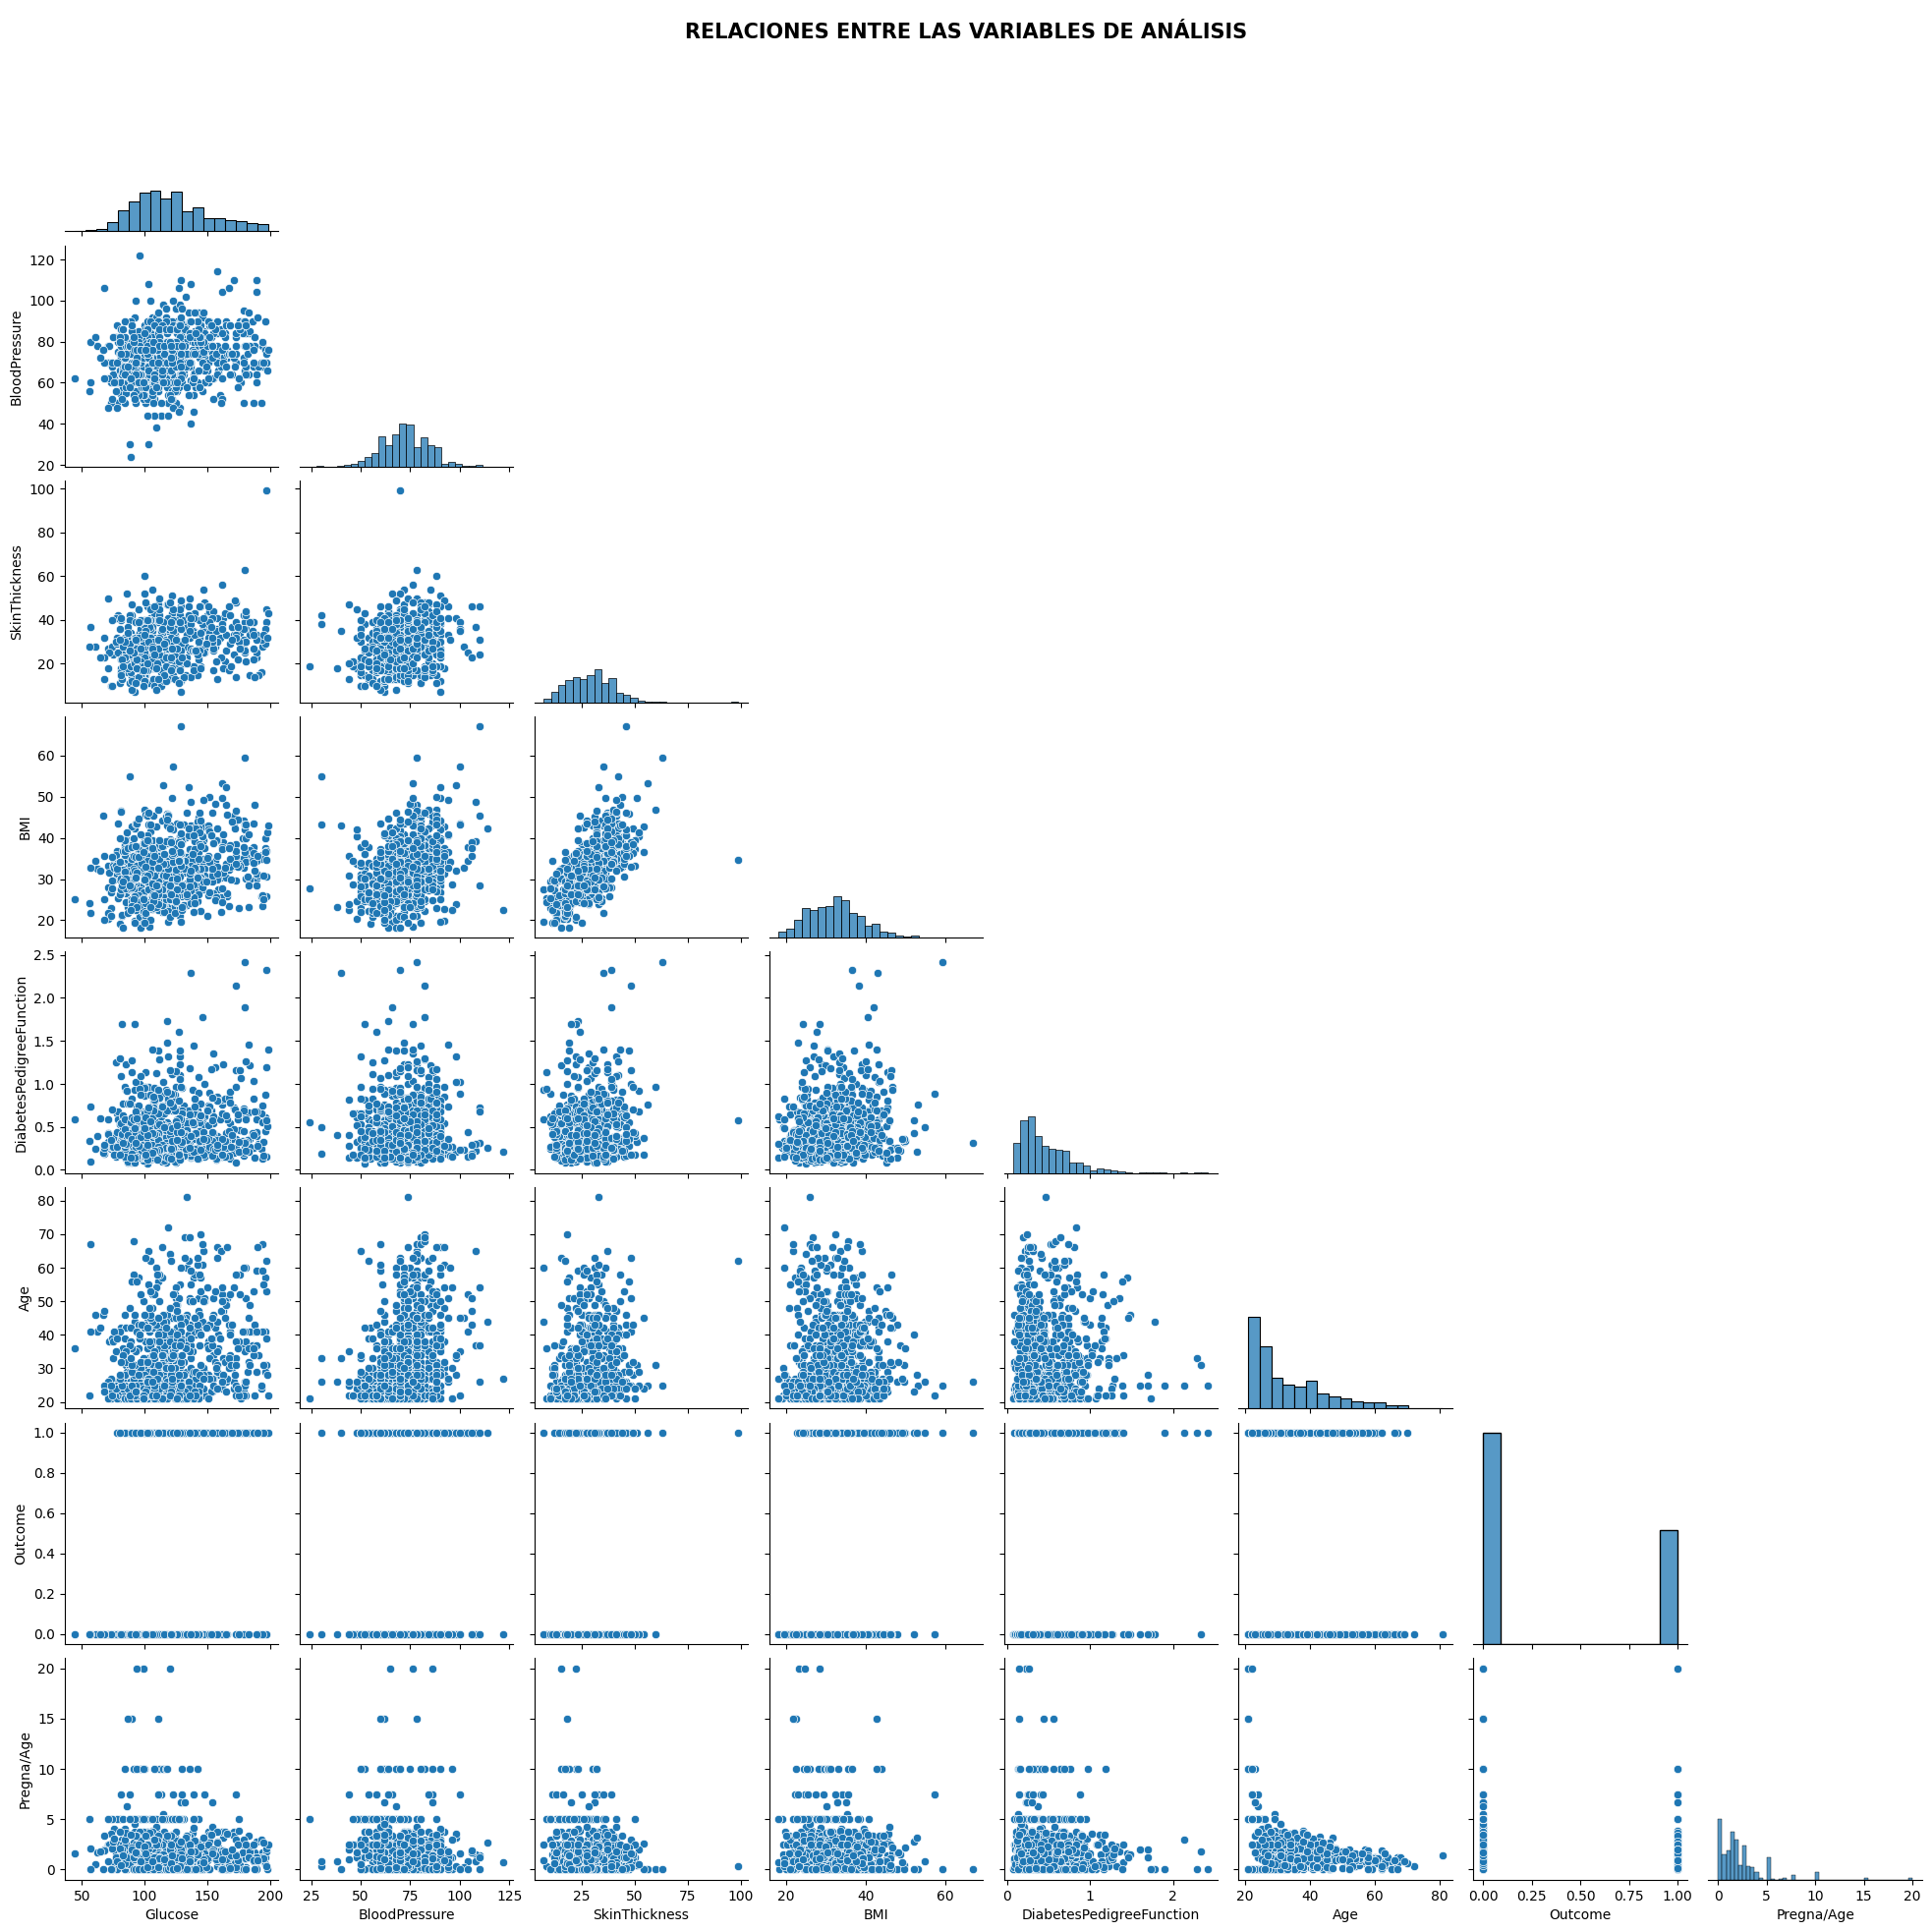

In [26]:
sns.pairplot(data=df.drop(columns="Pregnancies"), corner=True)
plt.suptitle("Relaciones entre las variables de análisis".upper(), fontweight="bold", size=15)
plt.plot()

## 1.5. División Train-Test

In [27]:
X = df.drop(columns=['Outcome', 'Pregnancies'],axis=1)
y = df['Outcome']
X_train, X_test, y_train, y_test=train_test_split(X,y, test_size=0.2, random_state=42)
X_train.head()

,Glucose,BloodPressure,SkinThickness,BMI,DiabetesPedigreeFunction,Age,Pregna/Age
364,147.00000,74.00000,25.00000,34.90000,0.38500,30,2.00000
269,146.00000,NaN,NaN,27.50000,0.24000,28,1.25000
93,134.00000,72.00000,NaN,23.80000,0.27700,60,0.62500
372,84.00000,64.00000,22.00000,35.80000,0.54500,21,0.00000
582,121.00000,78.00000,17.00000,26.50000,0.25900,62,1.87500


### 1.5.1. Imputación de Missing Values

In [28]:
#Columnas con valores nulos
round(X_train.isna().sum()/X_train.shape[0]*100,2).sort_values(ascending=False)

SkinThickness              27.14000
BloodPressure               3.12000
Glucose                     0.66000
BMI                         0.66000
DiabetesPedigreeFunction    0.00000
Age                         0.00000
Pregna/Age                  0.00000
dtype: float64

In [29]:
#Instanciamos MissForest
imputer = MissForest()

#Base de datos train
## - .fit_transform() entrena el modelo y predice los valores faltantes
X_train_imp = pd.DataFrame(imputer.fit_transform(X_train), columns=X_train.columns, index=X_train.index)

#Base de datos test
## - .transform() aplica el modelo anterior en unos nuevos datos
X_test_imp = pd.DataFrame(imputer.transform(X_test), columns=X_test.columns, index=X_test.index)

100%|██████████| 5/5 [00:00<00:00, 96.82it/s]


In [30]:
# Comprobamos eliminacion de missing values
X_train_imp.isna().sum()[X_train_imp.isna().sum()>0]/len(X_train_imp)*100

Series([], dtype: float64)

## 1.6. Análisis de valores Outliers

In [31]:
X_train_imp.describe().T

,count,mean,std,min,25%,50%,75%,max
Glucose,608.00000,121.77236,30.09359,56.00000,100.00000,118.00000,140.00000,199.00000
BloodPressure,608.00000,71.94767,11.96994,24.00000,64.00000,72.00000,80.00000,122.00000
SkinThickness,608.00000,29.22852,9.16965,7.00000,24.00000,29.00000,34.00000,99.00000
BMI,608.00000,32.50085,6.70605,18.20000,27.60000,32.40000,36.60000,59.40000
DiabetesPedigreeFunction,608.00000,0.48068,0.33816,0.08400,0.24575,0.38900,0.63700,2.42000
Age,608.00000,33.48520,11.94592,21.00000,24.00000,29.00000,41.00000,81.00000
Pregna/Age,608.00000,2.17284,2.36452,0.00000,0.78742,1.66667,2.50000,20.00000


Para discenir si una variable presenta valores extremos (outliers), realizaremos dos estudios.

- Hallaremos el porcentaje de observaciones fuera del rango intercuantilico ajustado, de forma que analizaremos las variables que presente más de un 3% de observaciones.

- Hallaremos el porcentaje de desviación entre la media y la mediana, ya que los outliers altera esta cifra. De esta forma, analizaremos la variable que presente más de un 20% de desvianza.

In [32]:
ric=oulier_ric(X_train_imp)
med_mean=outlier_med(X_train_imp)
#Observaciones fuera del ric
print(ric[ric>3])
print("-"*40)
#Desviación media-mediana
print(med_mean[med_mean>20])

Pregna/Age                 4.93421
DiabetesPedigreeFunction   3.78289
dtype: float64
----------------------------------------
Pregna/Age                 30.37034
DiabetesPedigreeFunction   23.56751
dtype: float64


Entraremos a estudiar el caso de ``Pregna/Age`` y de ``DiabetesPedigreeFunction``.

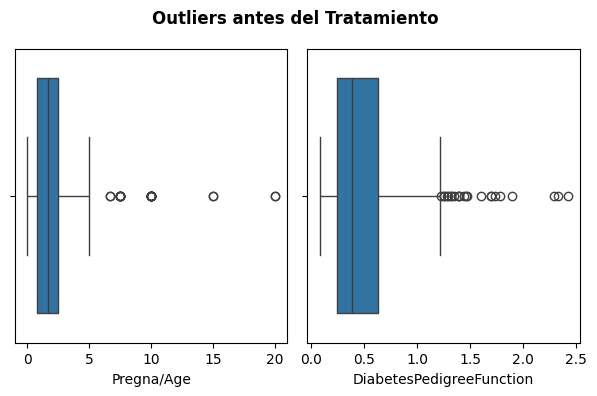

In [33]:
# Crear una figura con dos subplots (uno para el histograma y otro para el boxplot)
fig, axis = plt.subplots(1, 2, figsize=(6, 4))

# Crear un histograma en el primer subplot
# Primera fila
sns.boxplot(data=X_train_imp, x="Pregna/Age", ax=axis[0])
sns.boxplot(data=X_train_imp, x="DiabetesPedigreeFunction", ax=axis[1])
fig.suptitle("Outliers antes del Tratamiento", fontweight="bold")


# Mostrar la figura
plt.tight_layout()
plt.show()

In [34]:
#Ajuste para poder mostrar el numero de embarazos
X["Pregnancies"]=df["Pregnancies"]
X_train_est, X_test_est=train_test_split(X, test_size=0.2, random_state=42)
X_train_est[X_train_est["Pregna/Age"]>5][["Pregna/Age","Pregnancies", "Age"]].describe()

,Pregna/Age,Pregnancies,Age
count,30.00000,30.00000,30.00000
mean,10.11111,3.13333,21.63333
std,3.33142,1.33218,0.66868
min,6.66667,2.00000,21.00000
25%,7.50000,2.00000,21.00000
50%,10.00000,3.00000,22.00000
75%,10.00000,4.00000,22.00000
max,20.00000,8.00000,23.00000


Tras analizarlo, ``Pregna/Age`` lo dejaremos igual porque los outliers se concentran en personas jóvenes, mientras que aplicaremos logaritmos a ``DiabetesPedigreeFunction``.

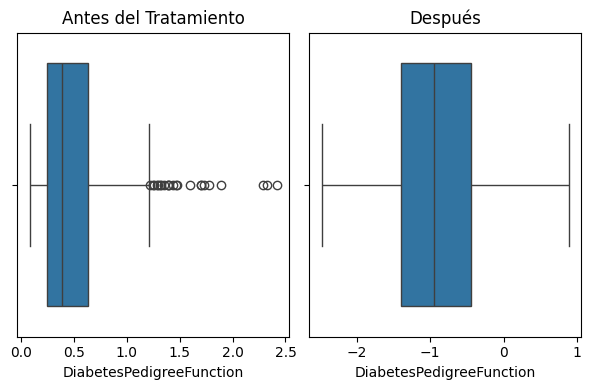

In [33]:
# Crear una figura con dos subplots (uno para el histograma y otro para el boxplot)
fig, axis = plt.subplots(1, 2, figsize=(6, 4))

# Crear un histograma en el primer subplot
# Primera fila
sns.boxplot(data=X_train_imp, x="DiabetesPedigreeFunction", ax=axis[0])
axis[0].set_title("Antes del Tratamiento")
sns.boxplot(x=np.log(X_train_imp["DiabetesPedigreeFunction"])+1e-4, ax=axis[1])
axis[1].set_title("Después")

# Mostrar la figura
plt.tight_layout()
plt.show()

In [34]:
# Aplicamos logaritmos en variables estudiadas con outliers
# Realizamos los cambios en train
X_train_imp["DiabetesPedigreeFunction"]=np.log(X_train_imp["DiabetesPedigreeFunction"])+1e-4
## Realizamos los cambios en test
X_test_imp["DiabetesPedigreeFunction"]=np.log(X_test_imp["DiabetesPedigreeFunction"])+1e-4

In [35]:
#Exportamos la base de datos procedada
train=pd.concat([X_train_imp, y_train], axis=1)
test=pd.concat([X_test_imp, y_test], axis=1)
df_proc=pd.concat([train, test], axis=0)
df_proc.to_csv("diabetes.csv")

In [36]:
#Guardamos media de las bases de datos para replicarla en estudios posteriores
print(X_train_imp.mean(), "\n","-"*50,"\n",X_test_imp.mean())

Glucose                    121.77236
BloodPressure               71.94767
SkinThickness               29.22852
BMI                         32.50085
DiabetesPedigreeFunction    -0.94391
Age                         33.48520
Pregna/Age                   2.17284
dtype: float64 
 -------------------------------------------------- 
 Glucose                    122.33635
BloodPressure               74.14304
SkinThickness               29.13904
BMI                         32.25229
DiabetesPedigreeFunction    -0.99658
Age                         32.67974
Pregna/Age                   2.21159
dtype: float64


# **2. SELECCIÓN DE CARCATERÍSTICAS**

## 2.1. Aplicación de los métodos

In [37]:
#Seleccion definitiva de variables imputadas
X_train=X_train_imp
X_test=X_test_imp

### A) Feature importance con Random Forest

In [38]:
# Entrenamiento de RF
model = RandomForestClassifier(random_state=42,n_jobs=-1).fit(X_train, y_train)
# Importancia de características
importances = model.feature_importances_/model.feature_importances_.sum()*100
# Mostramos resultados
df_rf = pd.DataFrame({'feature': X_train.columns,'rf_importance': importances}).sort_values(by='rf_importance', ascending=False)
df_rf

,feature,rf_importance
0,Glucose,26.34990
3,BMI,16.07113
5,Age,14.91210
4,DiabetesPedigreeFunction,13.10054
2,SkinThickness,11.54149
6,Pregna/Age,9.59438
1,BloodPressure,8.43047


### B) Permutation/Shuffle importance con Gradient Boosting Classifier

Dado estamos trabajando con información médica, vamos a centrar nuestro estudio de permutation en la métrica de recall con el objetivo de minimizar el número de falsos positivos.

In [39]:
# Para esta técnica y la de shap se necesita conjunto de validación
X_train1, X_val, y_train1, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=42)
# Entrenamos el modelo que va a porporcionarnos las predicciones por cada alteracion
model_xgb = XGBClassifier(random_state=42).fit(X_train1, y_train1)
# Intanciamos permitation forest
perm = permutation_importance(model_xgb, X_val, y_val, n_repeats=10, random_state=42, n_jobs=-1, scoring='recall')
## Extraemos los valores a un df
df_perm = pd.DataFrame({'feature': X_train1.columns, 'perm_imp': perm.importances_mean*100}).sort_values('perm_imp', ascending=False)
df_perm

,feature,perm_imp
3,BMI,13.33333
0,Glucose,13.33333
5,Age,7.84314
4,DiabetesPedigreeFunction,4.11765
2,SkinThickness,2.54902
6,Pregna/Age,1.17647
1,BloodPressure,-1.17647


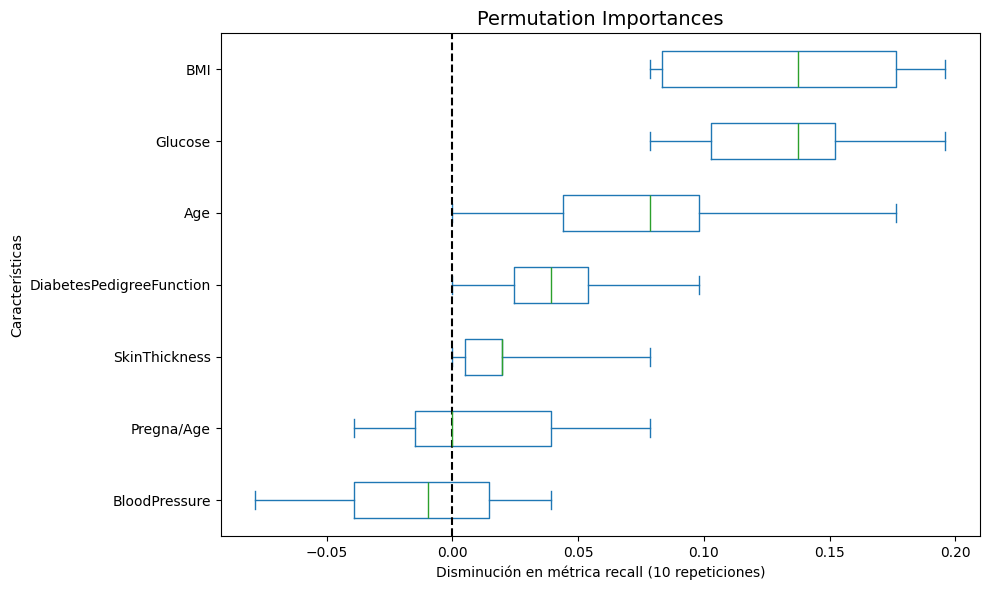

In [40]:
# Obtenemos orden de las variables (de menor a mayor importancia media)
# Esto asegura que el gráfico final estará ordenado
sorted_idx = perm.importances_mean.argsort()

# DataFrame para el Box Plot
# - Perm.importances: todos cambios en f1 por el numero de  repeticiones 
importances_df = pd.DataFrame(
    perm.importances[sorted_idx].T,
    columns=X_train.columns[sorted_idx] 
)
importances_df

#Representamos gráficamente los cambios en el f1 score
fig, ax = plt.subplots(figsize=(10, 6))

# Usamos .plot.box() directamente sobre el DataFrame (columna por columna)
# vert=False -> gráfico horizontal
ax = importances_df.plot.box(vert=False, whis=10, ax=ax)
ax.set_title("Permutation Importances", fontsize=14)
ax.set_ylabel("Características")
ax.axvline(x=0, color="k", linestyle="--") # Línea vertical en 0 (sin ganancia/pérdida)
ax.set_xlabel("Disminución en métrica recall (10 repeticiones)") 
fig.tight_layout()
plt.show()

### C) SHAP

In [41]:
# Ajustamos un modelo predictor para analizar la importancia de cada caract.
model_gbc = GradientBoostingClassifier(random_state=42).fit(X_train1, y_train1) 
# Instanciamos el shap explainer y extraemos los valores
explainer = shap.Explainer(model_gbc, X_val)  
shap_vals = explainer(X_val).values
# Pasamos los valores absolutos a un df
imp_shap = np.abs(shap_vals).mean(axis=0)
imp_shap_pct = imp_shap/imp_shap.sum()*100
df_shap = pd.DataFrame({"feature": X_train.columns, "shap_imp": imp_shap_pct}).sort_values('shap_imp', ascending=False)
df_shap

,feature,shap_imp
0,Glucose,28.95806
5,Age,21.37584
3,BMI,15.28300
4,DiabetesPedigreeFunction,11.83303
2,SkinThickness,10.66006
1,BloodPressure,6.83046
6,Pregna/Age,5.05956


## 2.2. Selección de característica según los 3 métodos

In [42]:
#Añadimos resultados a un único df
df_importances = (
    df_rf
    .merge(df_perm, on='feature', how='outer')
    .merge(df_shap, on='feature', how='outer')
).sort_values('perm_imp', ascending=False)

#Mostramos resultado
df_importances

,feature,rf_importance,perm_imp,shap_imp
1,BMI,16.07113,13.33333,15.28300
4,Glucose,26.34990,13.33333,28.95806
0,Age,14.91210,7.84314,21.37584
3,DiabetesPedigreeFunction,13.10054,4.11765,11.83303
6,SkinThickness,11.54149,2.54902,10.66006
5,Pregna/Age,9.59438,1.17647,5.05956
2,BloodPressure,8.43047,-1.17647,6.83046


In [43]:
# Eliminamos aquellas con un permutation importance negativo
df_sel=df_importances[(df_importances["rf_importance"]>2)&(df_importances["perm_imp"]>0)&(df_importances["shap_imp"]>2)]
df_sel

,feature,rf_importance,perm_imp,shap_imp
1,BMI,16.07113,13.33333,15.28300
4,Glucose,26.34990,13.33333,28.95806
0,Age,14.91210,7.84314,21.37584
3,DiabetesPedigreeFunction,13.10054,4.11765,11.83303
6,SkinThickness,11.54149,2.54902,10.66006
5,Pregna/Age,9.59438,1.17647,5.05956


In [44]:
# RESUMEN DE LA SELECCIÓN
## Seleccionados
sel=df_sel["feature"].tolist()
## Eliminados
### -Difference extrae las etiquetas que estan en un index pero no en otra colección
elm=X_train.columns.difference(sel).tolist()

##Condicional para verificar que mostramos todas las columnas
if X_train.shape[1]==(len(sel)+len(elm)):
    # Texto
    print(f"{len(elm)} columnas eliminadas:")
    print(elm)
    print("-"*120)
    print(f"{len(sel)} columnas seleccionadas:")
    print(sel)

else: print("Error al computar las columnas eliminadas")

1 columnas eliminadas:
['BloodPressure']
------------------------------------------------------------------------------------------------------------------------
6 columnas seleccionadas:
['BMI', 'Glucose', 'Age', 'DiabetesPedigreeFunction', 'SkinThickness', 'Pregna/Age']


## 2.3. Comprobación vif y correlaciones

In [45]:
# VIF
## Variable Xi: añdimos cte. para no asumir que regresión pasa por (0,0) y tener problemas con R2 de vif
x_vif=add_constant(X_train[sel])

## Cálculo: x_vif.values (array con los datos), i valor de la columna que asuma Yi
vif = pd.Series([variance_inflation_factor(x_vif.values, i) for i in range(x_vif.shape[1])], index=x_vif.columns).drop(index="const")
vif[vif>5]

Series([], dtype: float64)

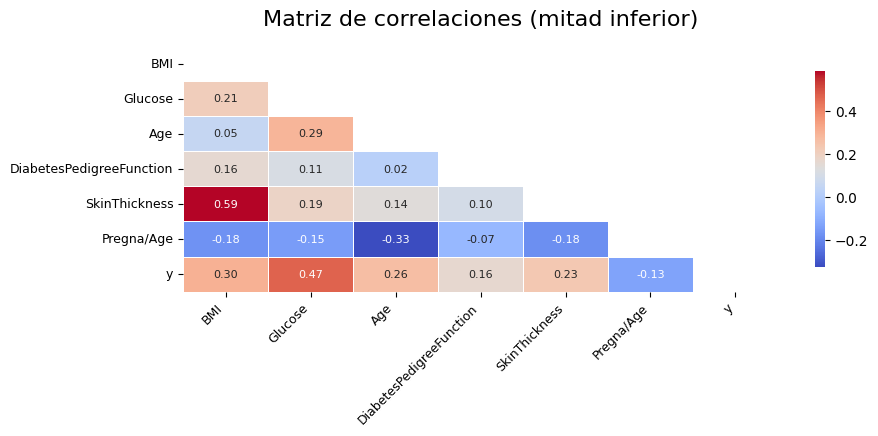

In [53]:
#Análisis de correlaciones entre regresores
x_vif.drop(columns="const", axis=1, inplace=True)
x_vif['y'] = y_train
corr = x_vif.corr()

#Mapa de correlaciones
plt.figure(figsize=(10, 5))
sns.heatmap(
    corr, mask=np.triu(np.ones_like(corr, dtype=bool)), 
    cmap='coolwarm',
    annot=True, fmt=".2f", linewidths=.5,
    cbar_kws={"shrink": .8},
    annot_kws={"size": 8}
)
plt.title("Matriz de correlaciones (mitad inferior)", fontsize=16, pad=15)
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(fontsize=9)
plt.tight_layout(pad=3.0)
plt.show()

Vamos a estudiar si el desarrollo de un ratio BMI/SkinThickness es suficiente para corregir esa correlación.

## 2.4. Ingeniería de características

Primero desarrollamos un estudio aislado, analizando si dicha transformación es significativa en un modelo logit, es decir, si hay relación estadistica entre ambas variables.

In [46]:
#Testamos ratio de variables correladas
ratio=pd.DataFrame(X_train['BMI']/X_train['SkinThickness'])
# Instanciar y entrenamos el modelo (solo define la función, aún no entrena)
test = sm.Logit(y_train, sm.add_constant(ratio)).fit()

Optimization terminated successfully.
         Current function value: 0.648130
         Iterations 5


In [47]:
# Guardamos los pvalores en una serie
result=test.pvalues
# Print de las variables resultantes
print(f"Variables significativas: {list(result[result<0.05].index)}" if len(result[result<0.05].index)>1 else "Ninguna variable es significativa")
print(f"Variables no significativas: {list(result[result>0.05].index)}" if len(result[result>0.05].index)>1 else "Todas las variables son significativas")

Ninguna variable es significativa
Variables no significativas: ['const', 0]


Parece que la transformación no es significativa, aunque lo terminaremos de verificar con cv.

## 2.5. Cross_validation

Vamos a analizar las siguientes estrategias:

1. Dejamos todas las variables correlacionadas
2. Eliminamos ``BMI``
3. Eliminamos ``SkinThickness``
4. Añadimos ``BMI``/``SkinThickness``

In [55]:
#Scorings de análisis
scorings=["f1", "recall", "precision"]
metrics1=[]
# Versión 1: todas las características
met1_x=x_vif.drop(columns=["y"])

#Cross validation por cada scoring
for scoring in scorings:
    cv_results1 = cross_val_score(RandomForestClassifier(random_state=42,n_jobs=-1), met1_x, y_train, cv=5, scoring=scoring)
    metrics1.append(float(round(cv_results1.mean()*100, 3)))

In [56]:
#Scorings de análisis
scorings=["f1", "recall", "precision"]
metrics2=[]
# Versión 2: eliminamos BMI
met2_x=met1_x.drop(columns=["BMI"])

#Cross validation por cada scoring
for scoring in scorings:
    cv_results2 = cross_val_score(RandomForestClassifier(random_state=42,n_jobs=-1), met2_x, y_train, cv=5, scoring=scoring)
    metrics2.append(float(round(cv_results2.mean()*100, 3)))

In [57]:
#Scorings de análisis
scorings=["f1", "recall", "precision"]
metrics3=[]
# Versión 3: eliminamos SkinThickness
met3_x=met1_x.drop(columns=["SkinThickness"])

#Cross validation por cada scoring
for scoring in scorings:
    cv_results3 = cross_val_score(RandomForestClassifier(random_state=42,n_jobs=-1), met3_x, y_train, cv=5, scoring=scoring)
    metrics3.append(float(round(cv_results3.mean()*100, 3)))

In [58]:
#Scorings de análisis
scorings=["f1", "recall", "precision"]
metrics4=[]
# Versión 4: calculamos ratio bmi/skin
met4_x=met1_x
met4_x["ratio_bmi_skin"]=met4_x['BMI']*met4_x['SkinThickness']
met4_x.drop(columns=["SkinThickness", "BMI"], inplace=True)

#Cross validation por cada scoring
for scoring in scorings:
    cv_results4 = cross_val_score(RandomForestClassifier(random_state=42,n_jobs=-1), met4_x, y_train, cv=5, scoring=scoring)
    metrics4.append(float(round(cv_results4.mean()*100, 3)))

In [59]:
# Tabla resumen
pd.DataFrame([metrics1, metrics2, metrics3, metrics4], index=["Df inicial", "- BMI", "- SkinThickness", "Df Ratio"], columns=scorings).sort_values(by="recall", ascending=False)

,f1,recall,precision
- SkinThickness,64.54200,60.68700,69.28500
Df inicial,64.08700,60.67700,68.99000
Df Ratio,63.23600,58.82700,68.50500
- BMI,58.87100,53.27700,66.10100


Luego, como eliminar ``SkinThickness`` no mejora mucho las metricas, optaremos por mantenerla pese a su elevada correlación.

# **3. MODELADO**

## 3.1. Entrenamiento

In [60]:
# Definimos espacio muestra
n=X_train.shape[0]
# Mostramos parámetros genéricos
print("Valores parámetros genéricos")
print("="*40)
print(f"max_depth: {round(np.log2(n/0.05*n)), round(np.log2(n/0.01*n))}")
print(f"min_samples_leaf: {round(0.01*n), round(0.05*n)}")
print(f"min_samples_split: {round(2*0.01*n), round(2*0.05*n)}")

Valores parámetros genéricos
max_depth: (23, 25)
min_samples_leaf: (6, 30)
min_samples_split: (12, 61)


In [63]:
# Definimos hiperparámetros
param_grid = {
    'max_depth': randint(2,23),
    'min_samples_leaf': randint(1,60),
    'min_samples_split': randint(2,120),
    'criterion': ["gini", "entropy"]}

# Configuramos búsqueda aleatoria
random_search = RandomizedSearchCV(
    estimator=DecisionTreeClassifier(random_state=42),
    param_distributions=param_grid,
    n_iter=20,                   # aumentar si tienes tiempo
    scoring='recall',
    cv=5,
    verbose=4,
    n_jobs=-1,
    random_state=42,
)

# Ejecutamos la búsqueda 
random_search.fit(X_train, y_train)
print("Mejores hiperparámetros:")
print(random_search.best_params_)
random_mod = random_search.best_estimator_ #Guardamos los resultados

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Mejores hiperparámetros:
{'criterion': 'entropy', 'max_depth': 4, 'min_samples_leaf': 22, 'min_samples_split': 54}


## 3.2. Evaluación

In [64]:
#Arbol resultante
##Predicciones
train_pred = random_mod.predict(X_train)
test_pred = random_mod.predict(X_test)
##Vemos los resultados
print(export_text(random_mod, feature_names=list(X_train.columns), class_names = ["No diabético", "Diabético"], show_weights=True))

|--- Glucose <= 127.50
|   |--- BMI <= 26.45
|   |   |--- Pregna/Age <= 3.66
|   |   |   |--- weights: [71.00, 0.00] class: No diabético
|   |   |--- Pregna/Age >  3.66
|   |   |   |--- weights: [21.00, 1.00] class: No diabético
|   |--- BMI >  26.45
|   |   |--- Age <= 28.50
|   |   |   |--- BMI <= 30.99
|   |   |   |   |--- weights: [48.00, 1.00] class: No diabético
|   |   |   |--- BMI >  30.99
|   |   |   |   |--- weights: [81.00, 19.00] class: No diabético
|   |   |--- Age >  28.50
|   |   |   |--- Glucose <= 99.50
|   |   |   |   |--- weights: [39.00, 5.00] class: No diabético
|   |   |   |--- Glucose >  99.50
|   |   |   |   |--- weights: [41.00, 53.00] class: Diabético
|--- Glucose >  127.50
|   |--- Glucose <= 159.50
|   |   |--- BMI <= 29.95
|   |   |   |--- weights: [38.00, 12.00] class: No diabético
|   |   |--- BMI >  29.95
|   |   |   |--- DiabetesPedigreeFunction <= -1.10
|   |   |   |   |--- weights: [23.00, 14.00] class: No diabético
|   |   |   |--- DiabetesPedigreeFu

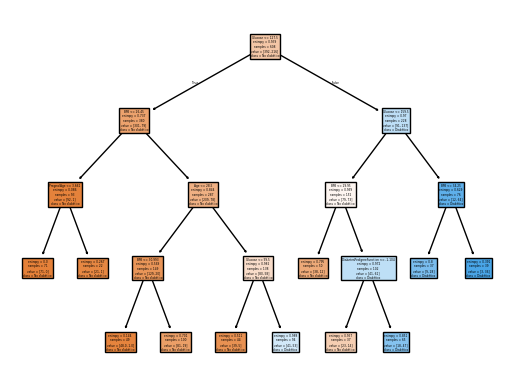

In [67]:
tree.plot_tree(random_mod, feature_names = list(X_train.columns), class_names = ['No diabético', 'Diabético'], filled = True)
plt.show()

In [68]:
## Métricas
print("-"*60)
print("GONFIGURACIÓN INICIAL")
print("-"*60)
print(metricas_clas(y_train, y_test, train_pred, test_pred))

------------------------------------------------------------
GONFIGURACIÓN INICIAL
------------------------------------------------------------
            Accuracy   Recall  Specificity  Precision      F1
Train        0.79770  0.75926      0.81888    0.69787 0.72727
Test         0.73203  0.76471      0.71569    0.57353 0.65546
Diferencia   0.06567 -0.00545      0.10319    0.12434 0.07181


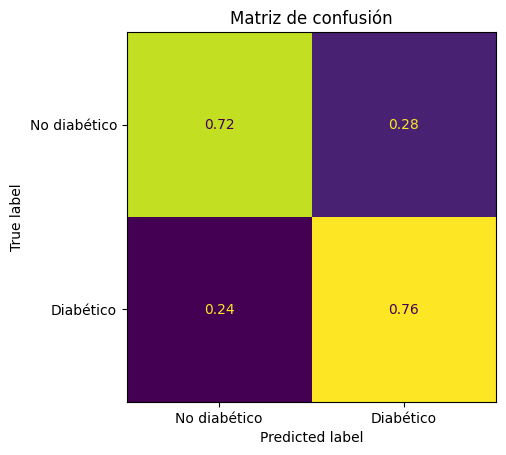

In [69]:
## Matriz de confusion
cm = confusion_matrix(y_test, test_pred, labels=[0, 1], normalize="true")
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=["No diabético", "Diabético"])
disp.plot(cmap="viridis", colorbar=False)
plt.title("Matriz de confusión")
plt.show()

Se aprecia como el modelo tiende a infraestimar el numero real de diabéticos y no diabéticos, de forma que clasifica incorrectamente como diabéticos al 28% de las personas no diabéticas.

## 3.3. Optimización de hiperparámetros

In [71]:
#Parámetros seleccionado anteriormente
print(random_search.best_params_)

{'criterion': 'entropy', 'max_depth': 4, 'min_samples_leaf': 22, 'min_samples_split': 54}


En este caso, nos centraremos en la profundidad, probando una concreción mucho más simple.

In [72]:
# Definimos hiperparámetro más importante
param_grid = {
    'max_depth': [3, 4, 5, 6]
    }

# Configurar GridSearchCV
grid_search = GridSearchCV(
    estimator=DecisionTreeClassifier(random_state=42),
    param_grid=param_grid,
    cv=5,  # 5-fold cross-validation 
    scoring='recall',  # Minimizamos FN
    n_jobs=-1,
    verbose=2  # Mostrar progreso
)

# Ejecutamos la búsqueda 
grid_search.fit(X_train, y_train)
print("Mejores hiperparámetros:")
print(grid_search.best_params_)
grid_mod = grid_search.best_estimator_ #Guardamos los resultados

##Predicciones
train_pred_opt = grid_mod.predict(X_train)
test_pred_opt = grid_mod.predict(X_test)

Fitting 5 folds for each of 4 candidates, totalling 20 fits
Mejores hiperparámetros:
{'max_depth': 4}


In [74]:
#Comparación de métricas
## Métricas
print("-"*60)
print("MODELO OPTIMIZAR")
print("-"*60)
print(metricas_clas(y_train, y_test, train_pred, test_pred))
## Métricas
print("-"*60)
print("MODELO FLEXIBLE")
print("-"*60)
print(metricas_clas(y_train, y_test, train_pred_opt, test_pred_opt))

------------------------------------------------------------
MODELO OPTIMIZAR
------------------------------------------------------------
            Accuracy   Recall  Specificity  Precision      F1
Train        0.79770  0.75926      0.81888    0.69787 0.72727
Test         0.73203  0.76471      0.71569    0.57353 0.65546
Diferencia   0.06567 -0.00545      0.10319    0.12434 0.07181
------------------------------------------------------------
MODELO FLEXIBLE
------------------------------------------------------------
            Accuracy  Recall  Specificity  Precision      F1
Train        0.81908 0.75463      0.85459    0.74091 0.74771
Test         0.74510 0.66667      0.78431    0.60714 0.63551
Diferencia   0.07398 0.08796      0.07028    0.13377 0.11219


[]

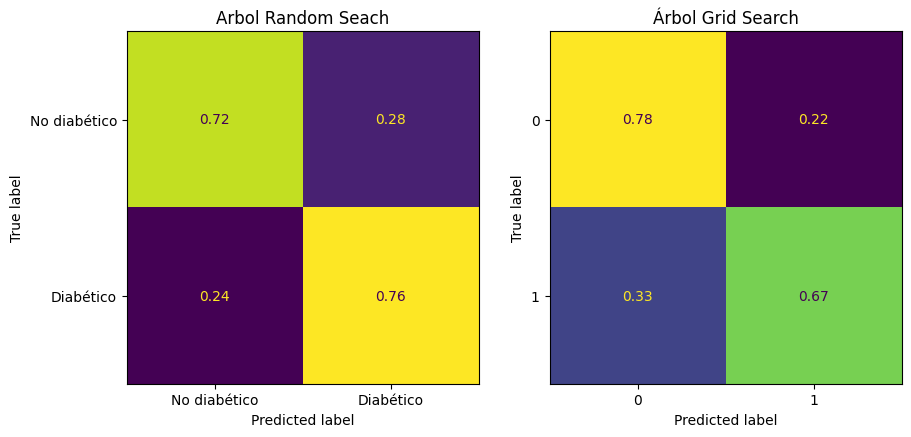

In [75]:
#Matriz de confusión
## Sin Optimizar
cm1 = confusion_matrix(y_test, test_pred, normalize='true')
## Optimizado
cm2 = confusion_matrix(y_test, test_pred_opt, normalize='true')

# Representación
fig, axis=plt.subplots(1,2, figsize=(10,5))
ConfusionMatrixDisplay(confusion_matrix=cm1, display_labels=["No diabético", "Diabético"]).plot(ax=axis[0],cmap='viridis',colorbar=False)
axis[0].set_title("Arbol Random Seach")
ConfusionMatrixDisplay(confusion_matrix=cm2).plot(ax=axis[1],cmap='viridis', colorbar=False)
axis[1].set_title("Árbol Grid Search")
plt.plot()

En este caso, nos quedaremos con la configuración de parametros de RandomSearch pues mantiene un mejor orden entre falsos positivos y negativos.

In [ ]:
#Exportamos el modelo tras la optimización de hiperparámetros
dump(random_mod, open("04-DT.sav", "wb")) #wb apertura del archivo en binario